## Prevendo a Ocorrência de Diabetes

## Conjunto de Dados do Repositório de Machine Learning da UCI / Kaggle
https://www.kaggle.com/uciml/pima-indians-diabetes-database/data

In [1]:
# Importando as bibliotecas
import pandas as pd                 
import seaborn as sns   
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Conjunto de Dados do Repositório de Machine Learning da UCI / Kaggle
df = pd.read_csv("pima-data.csv")
df.head()

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,skin,diabetes
0,6,148,72,35,0,33.6,0.627,50,1.3790,True
1,1,85,66,29,0,26.6,0.351,31,1.1426,False
2,8,183,64,0,0,23.3,0.672,32,0.0000,True
3,1,89,66,23,94,28.1,0.167,21,0.9062,False
4,0,137,40,35,168,43.1,2.288,33,1.3790,True


=== Criando o gráfico (Identificando a correlação entre as variáveis) ===


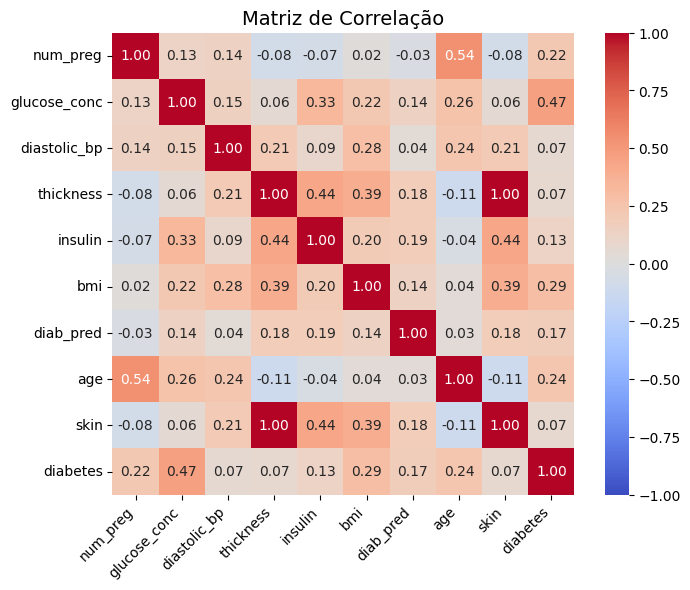

In [3]:
# A função corr() serve para calcular a correlação entre colunas numéricas. Indo -1 a 1
# Identificando a correlação entre as variáveis
def plot_corr(df):
    # Calcula a correlação das colunas
    corr = df.corr()

    plt.figure(figsize=(8, 6))

    # Cria o mapa de calor (heatmap)
    sns.heatmap(
        corr,
        annot=True,          # Mostra os valores dentro das células
        fmt=".2f",           # Formata os valores de dentro das células com 2 casas decimais
        cmap="coolwarm",     # Define qual é o mapa de cores
        square=True,         # Deixa as células quadradas
        cbar=True,           # Mostra barra de cores
        vmin=-1,             # Define o -1 como mínimo na escala da barra
        vmax=1,              # Define o 1 como o máximo na escala da barra
        center=0             # Define o 0 com centro
    )

    plt.title("Matriz de Correlação", fontsize=14)
    plt.xticks(rotation=45, ha="right")
    plt.yticks()
    plt.show()

# Criando o gráfico
print("=== Criando o gráfico (Identificando a correlação entre as variáveis) ===")
plot_corr(df)

In [4]:
# Visualizando a correlação em tabela
print("=== Coeficiente de correlação: ===\
       \n+1 = forte correlação positiva \n 0 = não há correlação \n-1 = forte correlação negativa")

df.corr()

=== Coeficiente de correlação: ===       
+1 = forte correlação positiva 
 0 = não há correlação 
-1 = forte correlação negativa


,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,skin,diabetes
num_preg,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,-0.081672,0.221898
glucose_conc,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.057328,0.466581
diastolic_bp,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.207371,0.065068
thickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,1.000000,0.074752
insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.436783,0.130548
bmi,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.392573,0.292695
diab_pred,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.183928,0.173844
age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,-0.113970,0.238356
skin,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,1.000000,0.074752
diabetes,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,0.074752,1.000000


In [5]:
# Definindo as classes
diabetes_map = {
    True : 1, 
    False : 0
}

# Aplicando o mapeamento ao dataset
df['diabetes'] = df['diabetes'].map(diabetes_map)

# Verificando como os dados estão distribuídos
print("=== Verificando como os dados estão distribuídos ===")

# loc serve para selecionar e alterar dados por nomes
# Buscando os dados com valor True e False, depois contando a quantidade de ocorrência de cada um
num_true = len(df.loc[df['diabetes'] == True])
num_false = len(df.loc[df['diabetes'] == False])

# len(df.index) retorna o tamanho do dataframe
total = len(df.index)

print(f"Número de Casos Verdadeiros: {num_true} ({(num_true/total) * 100:.2f}%)")
print(f"Número de Casos Falsos: {num_false} ({(num_false/ total) * 100:.2f}%)")

=== Verificando como os dados estão distribuídos ===
Número de Casos Verdadeiros: 268 (34.90%)
Número de Casos Falsos: 500 (65.10%)


## Spliting

70% para dados de treino e 30% para dados de teste

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
# Seleção de variáveis preditoras (independentes)
atributos = ['num_preg', 'glucose_conc', 'diastolic_bp', 'thickness', 'insulin', 'bmi', 'diab_pred', 'age']

# Variável a ser prevista (dependente)
atrib_prev = ['diabetes']

In [8]:
# Criando objetos
# Criando arrays com os valores das colunas atributos em X e atrib_prev em Y
X = df[atributos].values
Y = df[atrib_prev].values

# Criando dados de treino e de teste
# Aqui estou dividindo os dados de X e Y em 70% treino, 30% teste
X_treino, X_teste, Y_treino, Y_teste = train_test_split(X, Y, test_size = 0.30, random_state = 42)

# Imprimindo a porcentagem da divisão
print(f"{len(X_treino)/len(df.index) * 100:.2f}% nos dados de treino")
print(f"{len(X_teste)/len(df.index) * 100:.2f}% nos dados de teste")

69.92% nos dados de treino
30.08% nos dados de teste


## Construindo e treinando o modelo

In [9]:
from sklearn import metrics # Módulo com métricas de avaliação (accuracy, matriz de confusão..)
from sklearn.neural_network import MLPClassifier # Modelo de rede neural do tipo Multilayer Perceptron

In [10]:
# Instanciando o modelo.
# MLPClassifier() cria uma rede neural.random_state=42 fixa a aleatoriedade
modelo_v7 = MLPClassifier(random_state=42)
modelo_v7.fit(X_treino, Y_treino.ravel()) # .ravel() transforma o vetor alvo em um array 1D
''' Método fit() serve para:
        Ajusta os pesos da rede
        Aprende padrões nos dados
        Minimiza o erro usando backpropagation
fit vai usar as saidas obtidas do treino de X,
com as saídas em de Y treino e ajustar '''

' Método fit() serve para:\n        Ajusta os pesos da rede\n        Aprende padrões nos dados\n        Minimiza o erro usando backpropagation\nfit vai usar as saidas obtidas do treino de X,\ncom as saídas em de Y treino e ajustar '

In [11]:
# Aqui estou gerando previsões com o modelo
# Ele vai usar os valores de X mais os ajustes do fit para tentar prever as classes de Y
# Classes 0 = não diabetes, 1 = diabetes
mlp_predict_train = modelo_v7.predict(X_treino)
mlp_predict_test = modelo_v7.predict(X_teste)

## Súmario

Verdadeiro positivo (true positive — TP)

Ocorre quando no conjunto real a classe que estamos buscando foi prevista corretamente. Por exemplo, quando a pessoa está com diabetes e o modelo previu corretamente que a pessoa está com diabetes.

Falso positivo (false positive — FP)

Ocorre quando no conjunto real a classe que estamos buscando prever foi prevista incorretamente. Exemplo: a pessoa não está com diabetes, mas o modelo disse que está.

Falso verdadeiro (true negative — TN)

Ocorre quando no conjunto real a classe que não estamos buscando prever foi prevista corretamente. Exemplo: a pessoa não estava com diabetes, e o modelo previu corretamente que ela não está.

Falso negativo (false negative — FN)

Ocorre quando no conjunto real, a classe que não estamos buscando prever foi prevista incorretamente. Por exemplo, quando a pessoa está com diabetes e o modelo previu incorretamente que ela não está com diabetes.

In [12]:
tabela = pd.DataFrame(
    [["TP", "FP"],
     ["FN", "TN"]],
    columns=["Diabetes", "Não diabetes"],
    index=["Diabetes", "Não diabetes"]
)

In [13]:
# Comparando os valores que o modelo obteve no treino e no teste, com os valores reais de Y

# Calculando a porcentagem de acerto no treino e no teste
print("==================================================================================")
print(f"Exatidão (Accuracy) com os dados de treino do modelo MLPClassifier :\
 {metrics.accuracy_score(Y_treino, mlp_predict_train):.4f}")
print(f"Exatidão (Accuracy) com os dados de teste do modelo MLPClassifier:\
 {metrics.accuracy_score(Y_teste, mlp_predict_test):.4f}")

# O parâmetro labels=[1, 0] define a ordem que os dados vão aparecer
# Primeiro os dados que deram positivo(1) depois os dados negativos (0)

print("\nConfusion Matrix - Modelo MLPClassifier")
print(f"{metrics.confusion_matrix(Y_teste, mlp_predict_test, labels = [1, 0])}")
print(tabela)

print("\nClassification Report MLPClassifier")
print(metrics.classification_report(Y_teste, mlp_predict_test, labels = [1,0 ]))
print("==================================================================================")

Exatidão (Accuracy) com os dados de treino do modelo MLPClassifier : 0.7914
Exatidão (Accuracy) com os dados de teste do modelo MLPClassifier: 0.7229

Confusion Matrix - Modelo MLPClassifier
[[ 44  36]
 [ 28 123]]
             Diabetes Não diabetes
Diabetes           TP           FP
Não diabetes       FN           TN

Classification Report MLPClassifier
              precision    recall  f1-score   support

           1       0.61      0.55      0.58        80
           0       0.77      0.81      0.79       151

    accuracy                           0.72       231
   macro avg       0.69      0.68      0.69       231
weighted avg       0.72      0.72      0.72       231



In [ ]:
# Função de predição para novos pacientes
def prever_diabetes(modelo, dados_paciente):
    """
    Faz predição de diabetes para um novo paciente
    
    Parâmetros:
    - modelo: modelo MLPClassifier treinado (modelo_v7)
    - dados_paciente: lista com 8 valores [num_preg, glucose_conc, diastolic_bp, 
                      thickness, insulin, bmi, diab_pred, age]
    
    Retorna:
    - Dicionário com resultado e probabilidades
    """
    
    # Converter para array numpy
    dados = np.array(dados_paciente).reshape(1, -1)
    
    # Fazer predição
    predicao = modelo.predict(dados)[0]
    probabilidades = modelo.predict_proba(dados)[0]
    
    # Preparar resultado
    resultado = {
        'tem_diabetes': bool(predicao),
        'probabilidade_diabetes': probabilidades[1],
        'probabilidade_sem_diabetes': probabilidades[0],
        'classe_prevista': 'DIABETES' if predicao == 1 else 'SEM DIABETES'
    }
    
    return resultado

In [ ]:
# Função para exibir resultado formatado
def exibir_resultado_predicao(resultado):
    """
    Exibe o resultado da predição de forma visual
    """
    print("=" * 70)
    print("                  RESULTADO DA ANÁLISE DE DIABETES")
    print("=" * 70)
    
    if resultado['tem_diabetes']:
        print("\n⚠️  RESULTADO: POSITIVO PARA DIABETES")
        print(f"    Probabilidade: {resultado['probabilidade_diabetes']:.1%}")
        print("\n⚠️  ATENÇÃO: O modelo indica risco elevado de diabetes.")
        print("    Recomenda-se consultar um médico para exames específicos.")
    else:
        print("\n✅ RESULTADO: NEGATIVO PARA DIABETES")
        print(f"    Probabilidade de não ter diabetes: {resultado['probabilidade_sem_diabetes']:.1%}")
        print("\n✅ O modelo indica baixo risco de diabetes.")
        print("    Continue com hábitos saudáveis e check-ups regulares.")
    
    print("\n" + "-" * 70)
    print("📊 DISTRIBUIÇÃO DE PROBABILIDADES:")
    print(f"    Sem diabetes: {resultado['probabilidade_sem_diabetes']:.2%}")
    print(f"    Com diabetes: {resultado['probabilidade_diabetes']:.2%}")
    print("=" * 70)
    
    print("\n📌 IMPORTANTE: Este é um modelo preditivo para fins educacionais.")
    print("   NÃO substitui diagnóstico médico profissional!")
    print("=" * 70 + "\n")

In [ ]:
# Função interativa para coletar dados do usuário
def coletar_dados_paciente():
    """
    Coleta dados do paciente via input interativo
    """
    print("\n" + "=" * 70)
    print("           ENTRADA DE DADOS DO PACIENTE")
    print("=" * 70 + "\n")
    
    perguntas = [
        ("Número de gestações: ", "num_preg"),
        ("Concentração de glicose (mg/dL): ", "glucose_conc"),
        ("Pressão arterial diastólica (mm Hg): ", "diastolic_bp"),
        ("Espessura da dobra cutânea (mm): ", "thickness"),
        ("Insulina sérica (mu U/ml): ", "insulin"),
        ("IMC - Índice de Massa Corporal: ", "bmi"),
        ("Função de pedigree de diabetes (0-2.5): ", "diab_pred"),
        ("Idade (anos): ", "age")
    ]
    
    dados = []
    
    for pergunta, campo in perguntas:
        while True:
            try:
                valor = float(input(pergunta))
                dados.append(valor)
                break
            except ValueError:
                print("❌ Por favor, insira um número válido!")
    
    print("\n✅ Dados coletados com sucesso!\n")
    return dados

In [ ]:
# Sistema completo de predição interativa
def sistema_predicao_interativo(modelo):
    """
    Sistema completo para fazer predições interativas
    Usa o modelo treinado para analisar novos pacientes
    """
    print("\n" + "🏥" * 35)
    print("       SISTEMA DE PREDIÇÃO DE DIABETES - VERSÃO INTERATIVA")
    print("🏥" * 35 + "\n")
    
    while True:
        # Coletar dados
        dados_paciente = coletar_dados_paciente()
        
        # Fazer predição
        resultado = prever_diabetes(modelo, dados_paciente)
        
        # Exibir resultado
        exibir_resultado_predicao(resultado)
        
        # Perguntar se deseja continuar
        continuar = input("\nDeseja analisar outro paciente? (s/n): ")
        if continuar.lower() != 's':
            print("\n👋 Encerrando sistema. Obrigado!")
            break
        print("\n" + "=" * 70 + "\n")

In [ ]:
# Predição com dados fornecidos diretamente
print("\n📋 EXEMPLO 1: Predição com dados fornecidos diretamente")
print("=" * 70)

# Dados de exemplo (substitua pelos valores reais do paciente)
exemplo_paciente = [6, 148, 72, 35, 125, 33.6, 0.627, 50]

resultado = prever_diabetes(modelo_v7, exemplo_paciente)
exibir_resultado_predicao(resultado)


📋 EXEMPLO 1: Predição com dados fornecidos diretamente
                  RESULTADO DA ANÁLISE DE DIABETES

⚠️  RESULTADO: POSITIVO PARA DIABETES
    Probabilidade: 56.5%

⚠️  ATENÇÃO: O modelo indica risco elevado de diabetes.
    Recomenda-se consultar um médico para exames específicos.

----------------------------------------------------------------------
📊 DISTRIBUIÇÃO DE PROBABILIDADES:
    Sem diabetes: 43.51%
    Com diabetes: 56.49%

📌 IMPORTANTE: Este é um modelo preditivo para fins educacionais.
   NÃO substitui diagnóstico médico profissional!

